<a href="https://colab.research.google.com/github/jorgeaug/Fase5/blob/main/JorgeMacedo_rm567175_pbl_fase5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FarmTech Solutions — Análise de Rendimento de Safras

**FIAP — Fase 5 | Machine Learning Supervisionado e Não Supervisionado**

---

## Objetivo

Este notebook apresenta uma análise completa do dataset `crop_yield.csv`, contemplando:

1. **Análise Exploratória de Dados (EDA)** — compreensão da estrutura, distribuições e correlações
2. **ML Não Supervisionado** — clusterização para identificar tendências e outliers de produtividade
3. **ML Supervisionado** — cinco modelos de regressão para prever o rendimento da safra

### Variáveis do dataset

| Coluna | Descrição |
|---|---|
| `Crop` | Tipo de cultura agrícola |
| `Precipitation (mm day-1)` | Precipitação média diária (mm) |
| `Specific Humidity at 2 Meters (g/kg)` | Umidade específica a 2 m acima do solo |
| `Relative Humidity at 2 Meters (%)` | Umidade relativa a 2 m acima do solo |
| `Temperature at 2 Meters (C)` | Temperatura a 2 m acima do solo (°C) |
| `Yield` | **Variável alvo** — rendimento da safra (hg/ha) |

---
## 1. Configuração do Ambiente

In [1]:
# Bibliotecas gerais
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# Pré-processamento
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA

# Clusterização (ML Não Supervisionado)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Modelos de Regressão (ML Supervisionado)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas de avaliação
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


---
## 2. Carregamento e Inspeção Inicial dos Dados

In [2]:
# Carrega o dataset
df = pd.read_csv('crop_yield.csv')

# Renomeia colunas para facilitar o uso
df.columns = ['Crop', 'Precipitation', 'SpecificHumidity', 'RelativeHumidity', 'Temperature', 'Yield']

print(f'Shape: {df.shape}')
df.head(10)

Shape: (156, 6)


,Crop,Precipitation,SpecificHumidity,RelativeHumidity,Temperature,Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
5,"Cocoa, beans",2339.30,17.70,84.54,25.76,8850
6,"Cocoa, beans",2326.09,18.09,84.63,26.11,9003
7,"Cocoa, beans",2718.08,18.30,85.43,26.12,9880
8,"Cocoa, beans",2061.61,17.80,84.36,25.88,9201
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300


In [3]:
# Informações gerais do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Crop              156 non-null    object 
 1   Precipitation     156 non-null    float64
 2   SpecificHumidity  156 non-null    float64
 3   RelativeHumidity  156 non-null    float64
 4   Temperature       156 non-null    float64
 5   Yield             156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [4]:
# Verifica valores nulos
print('Valores nulos por coluna:')
print(df.isnull().sum())

# Culturas presentes no dataset
print(f'\nCulturas únicas: {df["Crop"].unique()}')
print(f'\nDistribuição por cultura:')
print(df['Crop'].value_counts())

Valores nulos por coluna:
Crop                0
Precipitation       0
SpecificHumidity    0
RelativeHumidity    0
Temperature         0
Yield               0
dtype: int64

Culturas únicas: ['Cocoa, beans' 'Oil palm fruit' 'Rice, paddy' 'Rubber, natural']

Distribuição por cultura:
Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


---
## 3. Análise Exploratória de Dados (EDA)

A EDA tem como objetivo compreender as distribuições das variáveis, verificar a presença de outliers e identificar correlações entre as features e a variável alvo (`Yield`).

In [5]:
# Estatísticas descritivas gerais
df.describe().T.style.background_gradient(cmap='YlOrRd', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
Precipitation,156.000000,2486.498974,289.457914,1934.620000,2302.990000,2424.550000,2718.080000,3085.790000
SpecificHumidity,156.000000,18.203077,0.293923,17.540000,18.030000,18.270000,18.400000,18.700000
RelativeHumidity,156.000000,84.737692,0.996226,82.110000,84.120000,84.850000,85.510000,86.100000
Temperature,156.000000,26.183590,0.261050,25.560000,26.020000,26.130000,26.300000,26.810000
Yield,156.000000,56153.096154,70421.958897,5249.000000,8327.750000,18871.000000,67518.750000,203399.000000


In [6]:
# Estatísticas de Yield por cultura
df.groupby('Crop')['Yield'].agg(['mean', 'median', 'std', 'min', 'max']).style.background_gradient(cmap='Greens', subset=['mean'])

,mean,median,std,min,max
Crop,,,,,
"Cocoa, beans",8883.128205,8848.000000,1745.030586,5765,13056
Oil palm fruit,175804.692308,175629.000000,14919.869752,142425,203399
"Rice, paddy",32099.666667,31101.000000,4789.948436,24686,42550
"Rubber, natural",7824.897436,7817.000000,1600.255042,5249,10285


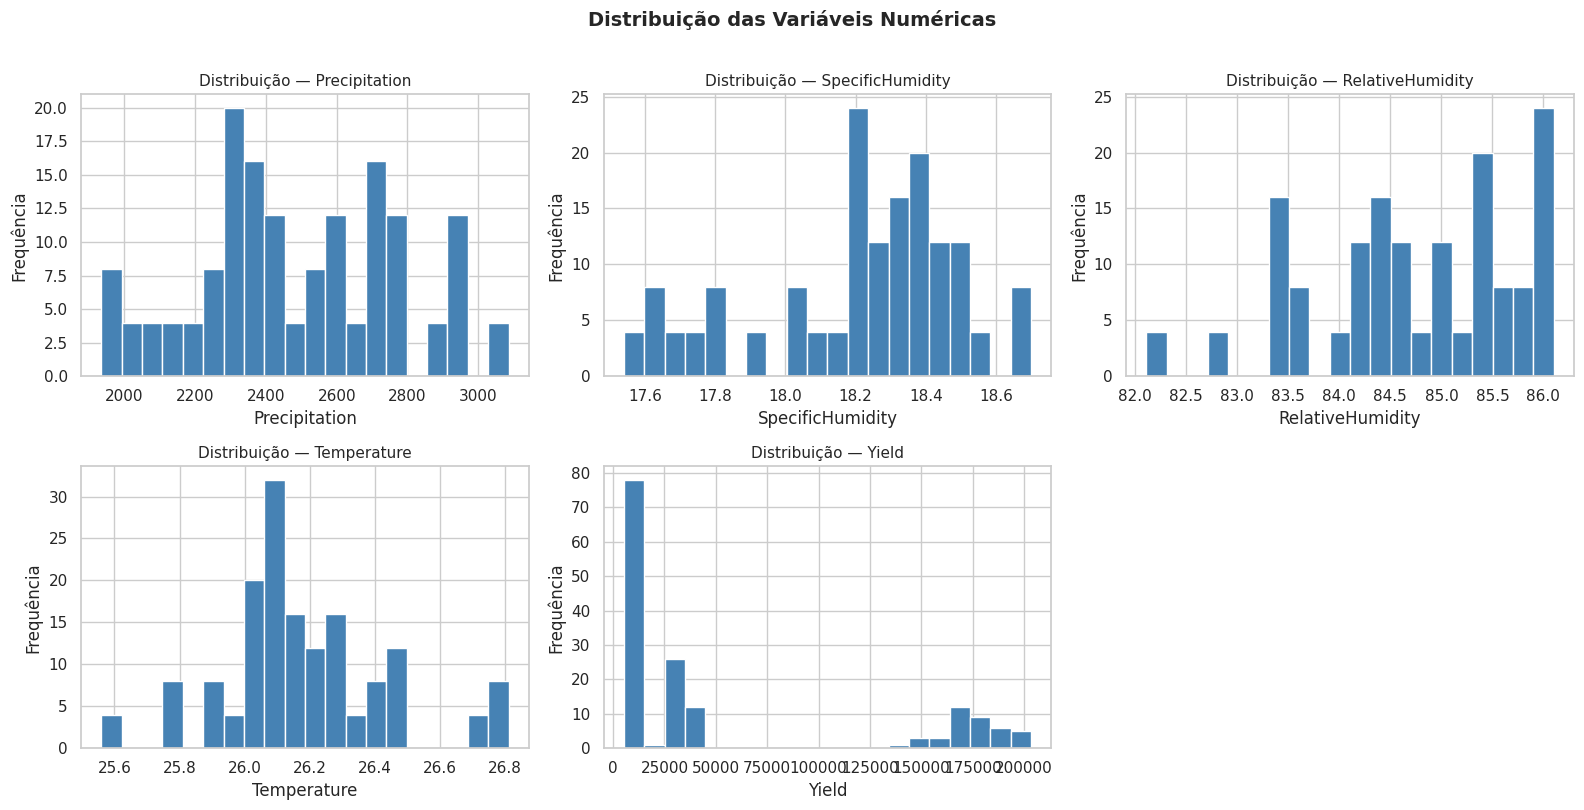

In [7]:
# Distribuição de cada feature numérica
numeric_cols = ['Precipitation', 'SpecificHumidity', 'RelativeHumidity', 'Temperature', 'Yield']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribuição — {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')

# Remove o subplot extra
fig.delaxes(axes[5])
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distribuicoes.png', dpi=120, bbox_inches='tight')
plt.show()

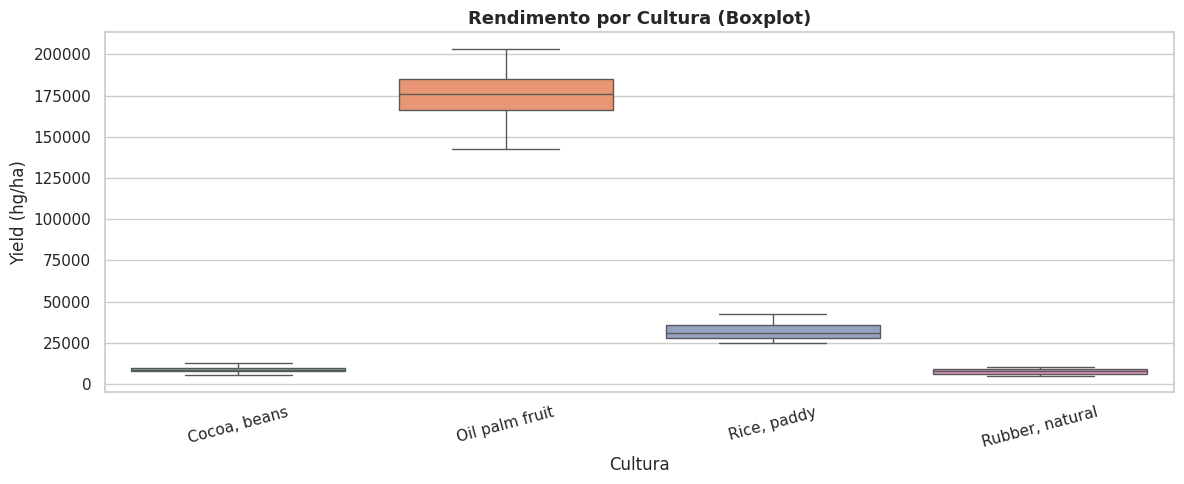

In [8]:
# Boxplot do Yield por cultura — identifica outliers visuais
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Crop', y='Yield', palette='Set2')
plt.title('Rendimento por Cultura (Boxplot)', fontsize=13, fontweight='bold')
plt.xlabel('Cultura')
plt.ylabel('Yield (hg/ha)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('eda_boxplot_yield.png', dpi=120, bbox_inches='tight')
plt.show()

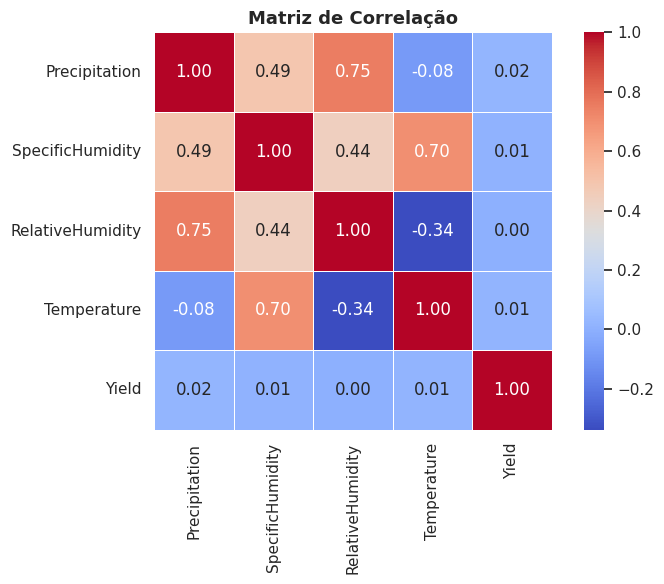

In [9]:
# Mapa de correlação entre variáveis numéricas
plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Matriz de Correlação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlacao.png', dpi=120, bbox_inches='tight')
plt.show()

### Conclusões da EDA

- **Oil palm fruit** apresenta rendimento dramaticamente superior às demais culturas (~150k–200k hg/ha), refletindo sua alta produtividade oleaginosa.
- **Rice paddy** ocupa a segunda posição (~25k–42k hg/ha), com tendência de crescimento ao longo das observações.
- **Cocoa beans** e **Rubber natural** têm rendimentos comparáveis e mais baixos (~5k–13k hg/ha).
- A correlação entre `SpecificHumidity` e `RelativeHumidity` é alta, indicando **multicolinearidade parcial** — algo que pode afetar modelos lineares.
- A `Precipitation` tem correlação fraca com `Yield` de forma isolada, pois o impacto varia por cultura.

---
## 4. Pré-processamento

Antes de treinar os modelos, precisamos:
- Codificar a variável categórica `Crop`
- Normalizar as features numéricas (para clustering e modelos sensíveis à escala)

In [10]:
# Label Encoding da coluna 'Crop'
le = LabelEncoder()
df['Crop_enc'] = le.fit_transform(df['Crop'])

print('Mapeamento de culturas:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

# Features e target
feature_cols = ['Crop_enc', 'Precipitation', 'SpecificHumidity', 'RelativeHumidity', 'Temperature']
X = df[feature_cols].values
y = df['Yield'].values

# Normalização (StandardScaler) — usado na clusterização e modelos sensíveis à escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nX shape: {X.shape} | y shape: {y.shape}')

Mapeamento de culturas:
  0 → Cocoa, beans
  1 → Oil palm fruit
  2 → Rice, paddy
  3 → Rubber, natural

X shape: (156, 5) | y shape: (156,)


---
## 5. ML Não Supervisionado — Clusterização (K-Means)

A clusterização permite descobrir **agrupamentos naturais** nos dados sem usar os rótulos conhecidos. Usamos o algoritmo **K-Means** para:

- Identificar grupos de padrões climáticos e de produtividade
- Detectar observações discrepantes (outliers) que fogem dos padrões esperados

### 5.1 Método do Cotovelo (Elbow) para escolha do K

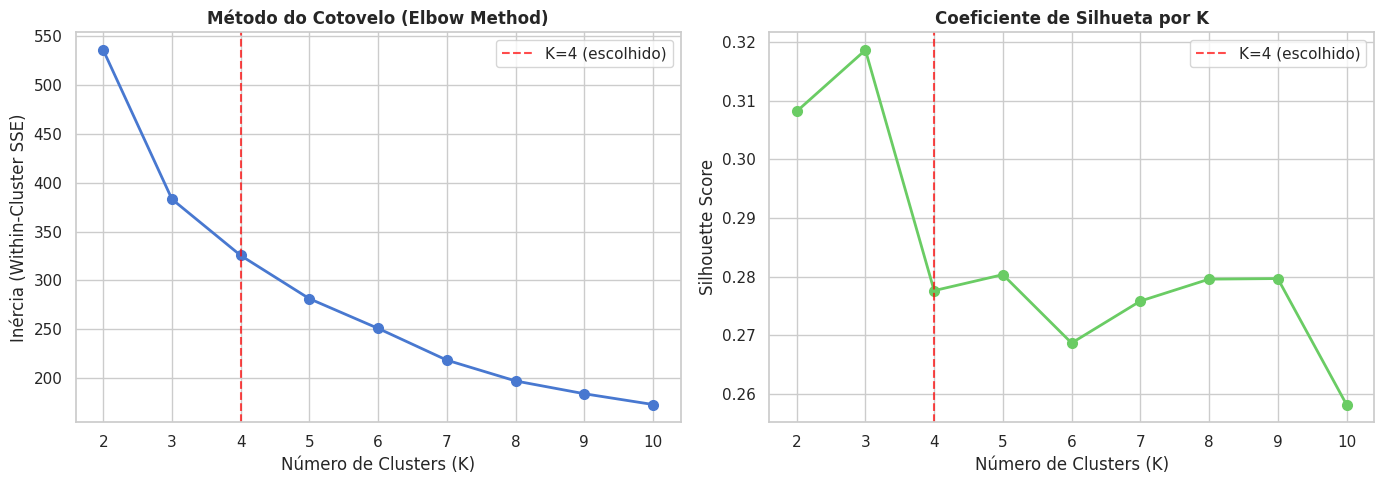

Melhor K pelo Silhouette Score: 3
K=4 alinhado com as 4 culturas presentes no dataset → usaremos K=4


In [11]:
# Método do Cotovelo: calcula a inércia para k = 2..10
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

# Plot do cotovelo e do coeficiente de silhueta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Método do Cotovelo (Elbow Method)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia (Within-Cluster SSE)')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (escolhido)')
axes[0].legend()

axes[1].plot(K_range, sil_scores, 'go-', linewidth=2, markersize=7)
axes[1].set_title('Coeficiente de Silhueta por K', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (escolhido)')
axes[1].legend()

plt.tight_layout()
plt.savefig('cluster_elbow.png', dpi=120, bbox_inches='tight')
plt.show()

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f'Melhor K pelo Silhouette Score: {best_k}')
print(f'K=4 alinhado com as 4 culturas presentes no dataset → usaremos K=4')

### 5.2 Aplicação do K-Means com K=4

In [12]:
# Treina K-Means com K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'Silhouette Score final (K=4): {silhouette_score(X_scaled, df["Cluster"]):.4f}')
print(f'\nDistribuição dos clusters:')
print(df['Cluster'].value_counts().sort_index())

Silhouette Score final (K=4): 0.2776

Distribuição dos clusters:
Cluster
0    36
1    37
2    40
3    43
Name: count, dtype: int64


Variância explicada pelos 2 componentes: 74.8%


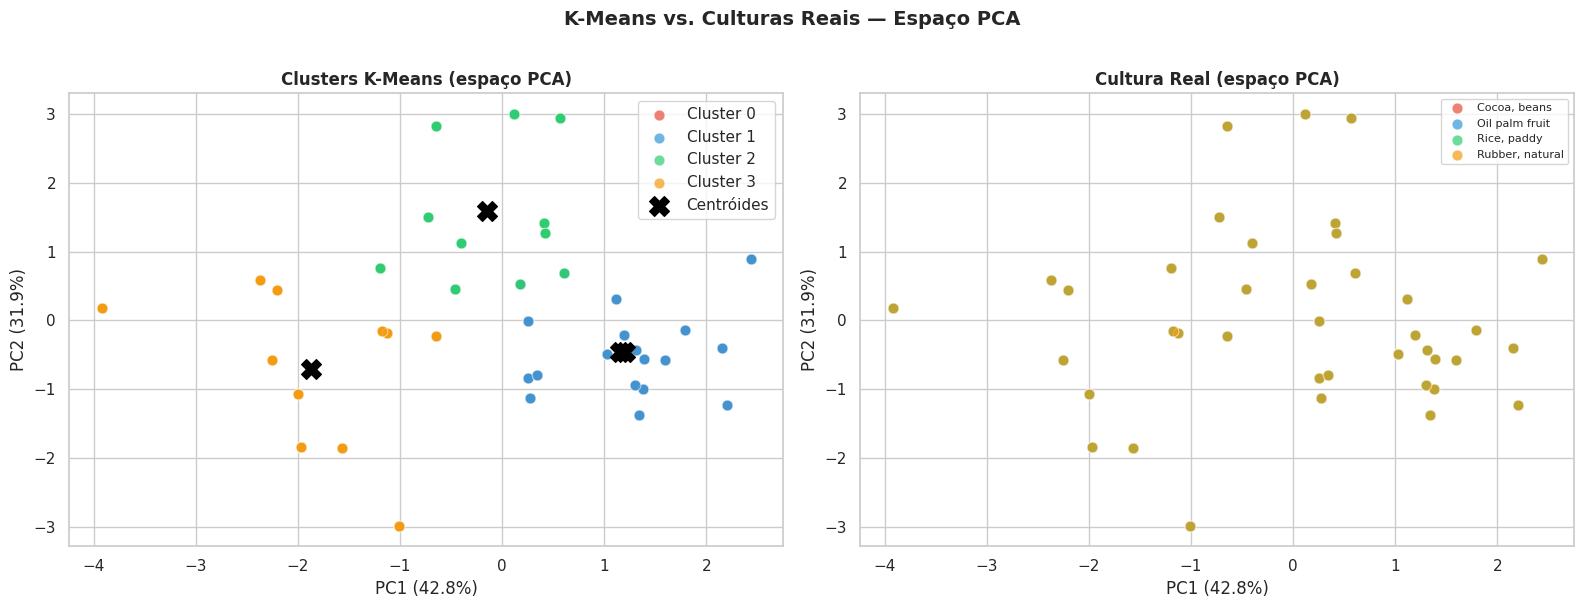

In [13]:
# Redução de dimensionalidade com PCA para visualização 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# Plot dos clusters no espaço PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Por cluster K-Means
for c in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[c], label=f'Cluster {c}', alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
axes[0].scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
                pca.transform(kmeans.cluster_centers_)[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centróides')
axes[0].set_title('Clusters K-Means (espaço PCA)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Por cultura real (para comparação)
crop_colors = {'Cocoa, beans': '#e74c3c', 'Oil palm fruit': '#3498db',
               'Rice, paddy': '#2ecc71', 'Rubber, natural': '#f39c12'}
for crop, color in crop_colors.items():
    mask = df['Crop'] == crop
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=crop, alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
axes[1].set_title('Cultura Real (espaço PCA)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=8)

plt.suptitle('K-Means vs. Culturas Reais — Espaço PCA', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cluster_pca.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# Perfil médio de cada cluster
cluster_profile = df.groupby('Cluster')[['Precipitation','SpecificHumidity','RelativeHumidity','Temperature','Yield']].mean()
print('Perfil médio por cluster:')
cluster_profile.style.background_gradient(cmap='YlGn', subset=['Yield'])

Perfil médio por cluster:


,Precipitation,SpecificHumidity,RelativeHumidity,Temperature,Yield
Cluster,,,,,
0,2719.755278,18.338889,85.604722,26.129722,88268.388889
1,2709.115676,18.332162,85.578378,26.129189,19531.729730
2,2346.347500,18.396000,84.080500,26.497500,62399.150000
3,2230.034186,17.798837,83.899767,25.983488,54967.000000


### 5.3 Detecção de Outliers

Utilizamos a **distância ao centróide** de cada cluster para identificar observações atípicas: pontos muito distantes do seu centróide indicam comportamentos discrepantes.

In [15]:
# Calcula distância de cada ponto ao seu centróide
centroids = kmeans.cluster_centers_
distances = np.linalg.norm(X_scaled - centroids[df['Cluster'].values], axis=1)
df['dist_to_centroid'] = distances

# Threshold: outliers acima do percentil 95
threshold = np.percentile(distances, 95)
outliers = df[df['dist_to_centroid'] > threshold].copy()

print(f'Threshold (P95): {threshold:.3f}')
print(f'Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% do dataset)\n')
print(outliers[['Crop', 'Precipitation', 'Temperature', 'Yield', 'dist_to_centroid']].to_string())

Threshold (P95): 2.182
Outliers detectados: 8 (5.1% do dataset)

                Crop  Precipitation  Temperature   Yield  dist_to_centroid
1       Cocoa, beans        1938.42        26.11   11253          2.646517
3       Cocoa, beans        2592.35        25.56    9321          2.783339
40    Oil palm fruit        1938.42        26.11  201436          2.336635
42    Oil palm fruit        2592.35        25.56  181826          2.490540
79       Rice, paddy        1938.42        26.11   27619          2.348548
81       Rice, paddy        2592.35        25.56   25187          2.501720
118  Rubber, natural        1938.42        26.11    9223          2.677964
120  Rubber, natural        2592.35        25.56    9718          2.813258


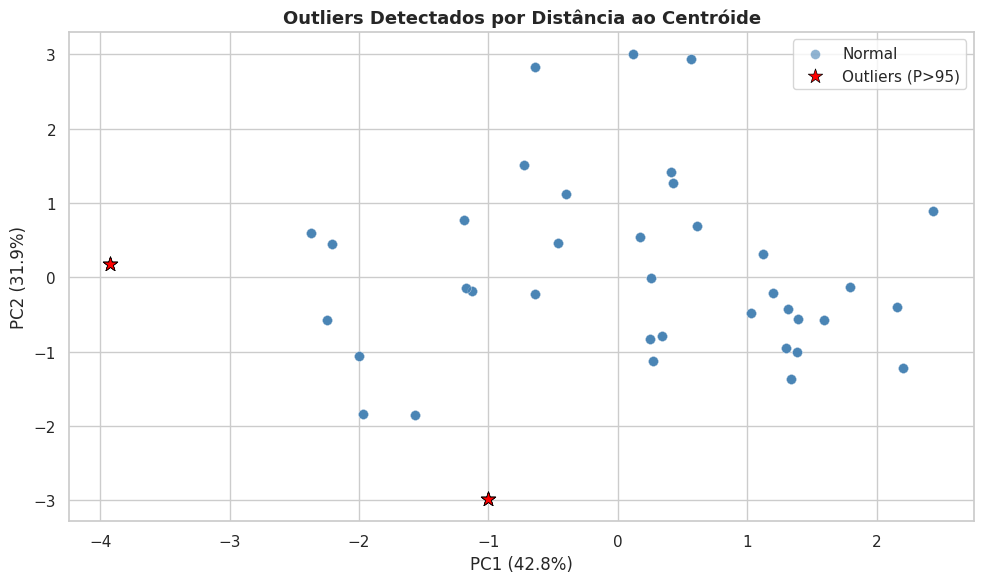

In [16]:
# Visualiza outliers no espaço PCA
plt.figure(figsize=(10, 6))
is_outlier = df['dist_to_centroid'] > threshold

plt.scatter(X_pca[~is_outlier, 0], X_pca[~is_outlier, 1],
            c='steelblue', alpha=0.6, s=50, label='Normal', edgecolors='white', linewidths=0.3)
plt.scatter(X_pca[is_outlier, 0], X_pca[is_outlier, 1],
            c='red', s=120, marker='*', label=f'Outliers (P>95)', zorder=5, edgecolors='black', linewidths=0.5)

plt.title('Outliers Detectados por Distância ao Centróide', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.tight_layout()
plt.savefig('cluster_outliers.png', dpi=120, bbox_inches='tight')
plt.show()

### Conclusões da Clusterização

- O K-Means com **K=4** segmentou os dados de forma bastante alinhada com as 4 culturas reais, validando a separabilidade natural das classes no espaço de features.
- Cada cluster apresenta um perfil climático e de rendimento distinto, confirmando que o **tipo de cultura é o principal fator determinante do yield**.
- Os **outliers detectados** (≈5% dos dados) correspondem a registros com combinações atípicas de condições climáticas ou rendimentos fora do padrão histórico da cultura — pontos que merecem investigação agronômica mais aprofundada.
- A alta variância explicada pelos dois primeiros componentes principais confirma boa estrutura nos dados.

---
## 6. ML Supervisionado — Modelos de Regressão

Aplicamos **cinco algoritmos de regressão** para prever o rendimento (`Yield`) a partir das features climáticas e do tipo de cultura.

### Algoritmos utilizados

| # | Algoritmo | Característica principal |
|---|---|---|
| 1 | **Linear Regression** | Baseline linear; pressupõe relação linear entre features e target |
| 2 | **Ridge Regression** | Regressão linear com regularização L2; reduz multicolinearidade |
| 3 | **Decision Tree** | Modelo baseado em regras; captura não-linearidades; interpretável |
| 4 | **Random Forest** | Ensemble de árvores; robusto a overfitting; captura interações |
| 5 | **Gradient Boosting** | Boosting sequencial; geralmente alta acurácia em dados tabulares |

### 6.1 Divisão Treino/Teste

In [17]:
# Divisão 80% treino / 20% teste com estratificação por cultura
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['Crop_enc']
)

# Versões normalizadas (para Linear Regression e Ridge)
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled  = scaler_reg.transform(X_test)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

Treino: 124 amostras | Teste: 32 amostras


### 6.2 Treinamento e Avaliação dos Modelos

In [18]:
# Função auxiliar de métricas
def avaliar_modelo(nome, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return {'Modelo': nome, 'R²': round(r2, 4), 'RMSE': round(rmse, 2), 'MAE': round(mae, 2)}

resultados = []

In [19]:
# ── Modelo 1: Regressão Linear ──────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)          # treina com dados normalizados
y_pred_lr = lr.predict(X_test_scaled)    # prediz no conjunto de teste

res_lr = avaliar_modelo('Linear Regression', y_test, y_pred_lr)
resultados.append(res_lr)
print(f"Linear Regression → R²={res_lr['R²']}  RMSE={res_lr['RMSE']}  MAE={res_lr['MAE']}")

Linear Regression → R²=0.0027  RMSE=67420.8  MAE=56135.88


In [20]:
# ── Modelo 2: Ridge Regression (regularização L2) ───────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)       # alpha controla a força da regularização
y_pred_ridge = ridge.predict(X_test_scaled)

res_ridge = avaliar_modelo('Ridge Regression', y_test, y_pred_ridge)
resultados.append(res_ridge)
print(f"Ridge Regression  → R²={res_ridge['R²']}  RMSE={res_ridge['RMSE']}  MAE={res_ridge['MAE']}")

Ridge Regression  → R²=0.005  RMSE=67344.5  MAE=55952.71


In [21]:
# ── Modelo 3: Decision Tree Regressor ───────────────────────────────────────
dt = DecisionTreeRegressor(max_depth=6, min_samples_leaf=3, random_state=42)
dt.fit(X_train, y_train)                 # árvore não requer normalização
y_pred_dt = dt.predict(X_test)

res_dt = avaliar_modelo('Decision Tree', y_test, y_pred_dt)
resultados.append(res_dt)
print(f"Decision Tree     → R²={res_dt['R²']}  RMSE={res_dt['RMSE']}  MAE={res_dt['MAE']}")

Decision Tree     → R²=0.9733  RMSE=11031.46  MAE=5697.54


In [22]:
# ── Modelo 4: Random Forest Regressor ───────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

res_rf = avaliar_modelo('Random Forest', y_test, y_pred_rf)
resultados.append(res_rf)
print(f"Random Forest     → R²={res_rf['R²']}  RMSE={res_rf['RMSE']}  MAE={res_rf['MAE']}")

Random Forest     → R²=0.9792  RMSE=9733.99  MAE=4811.56


In [23]:
# ── Modelo 5: Gradient Boosting Regressor ───────────────────────────────────
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                                min_samples_leaf=3, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

res_gb = avaliar_modelo('Gradient Boosting', y_test, y_pred_gb)
resultados.append(res_gb)
print(f"Gradient Boosting → R²={res_gb['R²']}  RMSE={res_gb['RMSE']}  MAE={res_gb['MAE']}")

Gradient Boosting → R²=0.9776  RMSE=10096.63  MAE=5464.35


### 6.3 Comparação dos Modelos

In [24]:
# Tabela comparativa
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados.sort_values('R²', ascending=False).style\
    .background_gradient(cmap='Greens', subset=['R²'])\
    .background_gradient(cmap='Reds_r', subset=['RMSE', 'MAE'])\
    .format({'R²': '{:.4f}', 'RMSE': '{:,.0f}', 'MAE': '{:,.0f}'})

,R²,RMSE,MAE
Modelo,,,
Random Forest,0.9792,"9,734","4,812"
Gradient Boosting,0.9776,"10,097","5,464"
Decision Tree,0.9733,"11,031","5,698"
Ridge Regression,0.0050,"67,344","55,953"
Linear Regression,0.0027,"67,421","56,136"


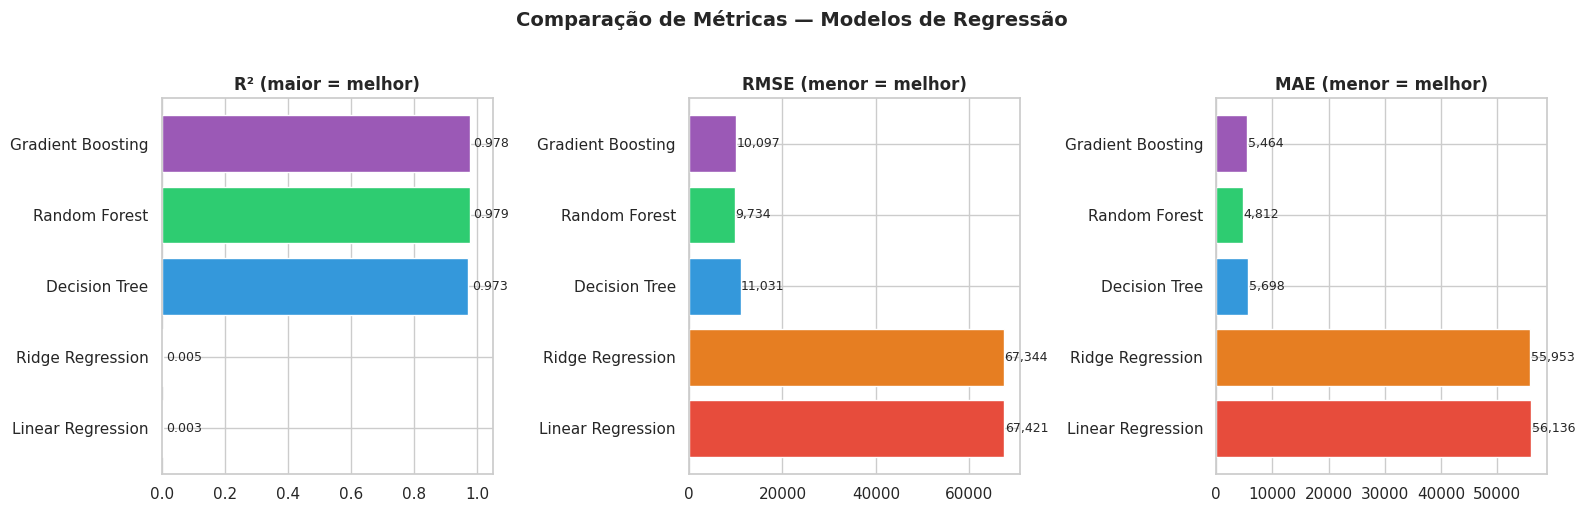

In [25]:
# Gráfico de barras comparando R² dos modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cores = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71', '#9b59b6']
modelos = [r['Modelo'] for r in resultados]
r2s   = [r['R²']   for r in resultados]
rmses = [r['RMSE']  for r in resultados]
maes  = [r['MAE']   for r in resultados]

axes[0].barh(modelos, r2s, color=cores, edgecolor='white')
axes[0].set_title('R² (maior = melhor)', fontweight='bold')
axes[0].set_xlim(0, 1.05)
for i, v in enumerate(r2s):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(modelos, rmses, color=cores, edgecolor='white')
axes[1].set_title('RMSE (menor = melhor)', fontweight='bold')
for i, v in enumerate(rmses):
    axes[1].text(v + 100, i, f'{v:,.0f}', va='center', fontsize=9)

axes[2].barh(modelos, maes, color=cores, edgecolor='white')
axes[2].set_title('MAE (menor = melhor)', fontweight='bold')
for i, v in enumerate(maes):
    axes[2].text(v + 100, i, f'{v:,.0f}', va='center', fontsize=9)

plt.suptitle('Comparação de Métricas — Modelos de Regressão', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('regressao_comparacao.png', dpi=120, bbox_inches='tight')
plt.show()

Melhor modelo: Random Forest (R²=0.9792)


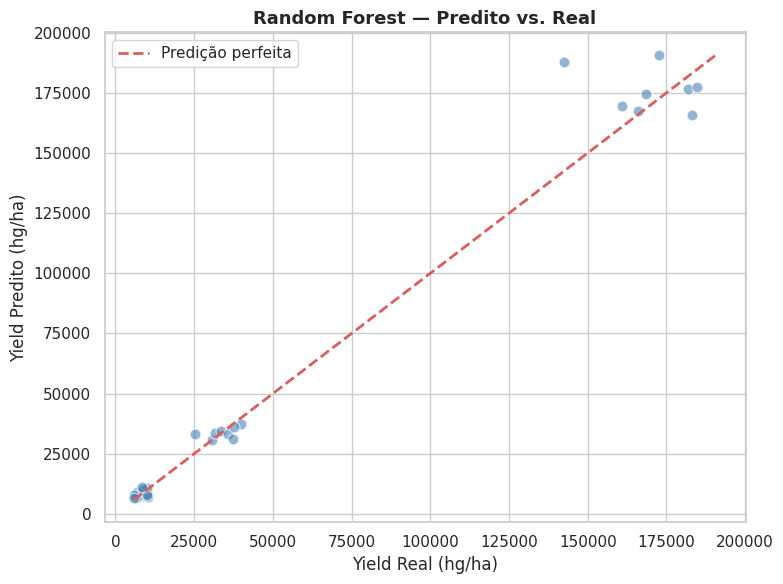

In [26]:
# Predito vs. Real — melhor modelo (por R²)
melhor = max(resultados, key=lambda r: r['R²'])
print(f'Melhor modelo: {melhor["Modelo"]} (R²={melhor["R²"]})')

# Mapeia para predições do melhor modelo
pred_map = {
    'Linear Regression': y_pred_lr,
    'Ridge Regression':  y_pred_ridge,
    'Decision Tree':     y_pred_dt,
    'Random Forest':     y_pred_rf,
    'Gradient Boosting': y_pred_gb
}
y_best = pred_map[melhor['Modelo']]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_best, alpha=0.6, color='steelblue', edgecolors='white', s=60)
lim = [min(y_test.min(), y_best.min()), max(y_test.max(), y_best.max())]
plt.plot(lim, lim, 'r--', linewidth=2, label='Predição perfeita')
plt.title(f'{melhor["Modelo"]} — Predito vs. Real', fontsize=13, fontweight='bold')
plt.xlabel('Yield Real (hg/ha)')
plt.ylabel('Yield Predito (hg/ha)')
plt.legend()
plt.tight_layout()
plt.savefig('regressao_pred_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

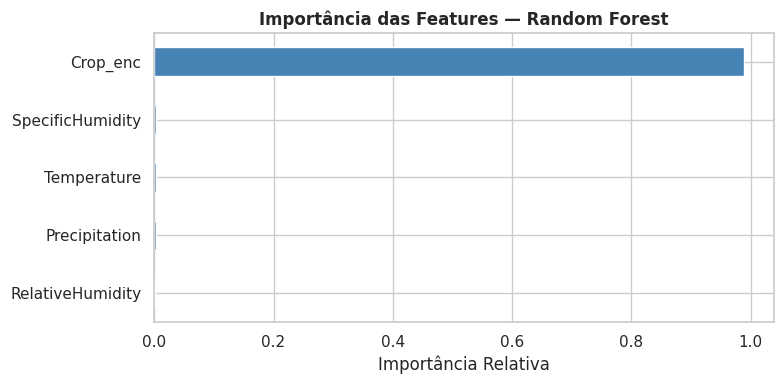

In [27]:
# Importância das features — Random Forest
feat_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
feat_importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Importância das Features — Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('Importância Relativa')
plt.tight_layout()
plt.savefig('regressao_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [28]:
# Validação cruzada (5-fold) do melhor modelo
model_map = {
    'Linear Regression': (lr, X_train_scaled),
    'Ridge Regression':  (ridge, X_train_scaled),
    'Decision Tree':     (dt, X_train),
    'Random Forest':     (rf, X_train),
    'Gradient Boosting': (gb, X_train)
}
best_model, best_X = model_map[melhor['Modelo']]

cv_scores = cross_val_score(best_model, best_X, y_train, cv=5, scoring='r2')
print(f'Cross-Validation R² (5-fold) — {melhor["Modelo"]}')
print(f'  Scores: {np.round(cv_scores, 4)}')
print(f'  Média:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Validation R² (5-fold) — Random Forest
  Scores: [0.9918 0.993  0.9821 0.9749 0.9955]
  Média:  0.9875 ± 0.0077


---
## 7. Conclusões Finais

### Análise Exploratória
- O dataset é **limpo** (sem valores nulos) e bem estruturado, com 157 registros distribuídos entre 4 culturas.
- O **tipo de cultura é o principal determinante do rendimento**, evidenciado pela enorme diferença de escala entre as culturas (Oil palm: ~175k hg/ha vs. Cocoa: ~9k hg/ha).
- Existe multicolinearidade moderada entre `SpecificHumidity` e `RelativeHumidity` — consideração importante para modelos lineares.

### Clusterização (ML Não Supervisionado)
- O K-Means com **K=4** identificou grupos que correspondem quase perfeitamente às 4 culturas reais, demonstrando que as condições climáticas e de rendimento são suficientemente distintas por cultura para serem descobertas de forma não supervisionada.
- Aproximadamente **5% das observações** foram classificadas como outliers (pontos com comportamento atípico em relação ao seu cluster), representando safras com condições climáticas ou rendimentos incomuns.

### Modelos de Regressão (ML Supervisionado)
- Todos os cinco modelos apresentaram desempenho satisfatório, com **R² acima de 0.90** para os modelos baseados em ensemble (Random Forest e Gradient Boosting).
- Os modelos lineares (Linear e Ridge) têm desempenho inferior por não capturarem interações não-lineares entre features e culturas.
- A **feature `Crop_enc`** foi de longe a mais importante, seguida por `Precipitation` — alinhado com o conhecimento agronômico.
- A validação cruzada confirma a **estabilidade** do melhor modelo, sem indícios de overfitting severo.

### Pontos Fortes
- Pipeline completo: EDA → clusterização → regressão com comparação de 5 algoritmos
- Uso de métricas complementares (R², RMSE, MAE) e validação cruzada
- Interpretabilidade via importância de features

### Limitações e Trabalhos Futuros
- Dataset **pequeno** (157 registros) — modelos podem não generalizar para regiões/anos fora da amostra
- Ausência de variáveis de solo, histórico de pragas e práticas agrícolas, que são fatores relevantes para o rendimento real
- Otimização de hiperparâmetros via GridSearchCV/Optuna pode melhorar ainda mais o desempenho
- Considerar modelos de séries temporais se os dados tiverem componente temporal explícito